In [1]:
import sys; print(sys.executable)
!jupyter kernelspec list
!jupyter kernelspec install /usr/local/share/jupyter/kernels/python312-ml-cpu --user --name orange-custom-kernel

"""
Duplicated the "/usr/local/share/jupyter/kernels/python312-ml-cpu" kernel by
jupyter kernelspec install /usr/local/share/jupyter/kernels/python312-ml-cpu --user --name orange-custom-kernel
Added  ",
"env": {
  "PYTHONPATH": "/stor/home/he4249/orange/my_custom_packages"
}"
And chose the kernel.
This is so n_jobs = -1 works and every child created inherits the PYTHONPATH to the libraries.
"""

/opt/jupyterhub-kernels/python312-ml-cpu/bin/python


[ListKernelSpecs] WARNING | Config option `runtime_dir` not recognized by `ListKernelSpecs`.
Available kernels:
  orange-custom-kernel    /stor/home/he4249/.local/share/jupyter/kernels/orange-custom-kernel
  python3                 /opt/jupyterhub-kernels/python312-ml-cpu/share/jupyter/kernels/python3
  ir                      /usr/local/share/jupyter/kernels/ir
  python312-bio           /usr/local/share/jupyter/kernels/python312-bio
  python312-ml-cpu        /usr/local/share/jupyter/kernels/python312-ml-cpu
  python312-ml-jax-cpu    /usr/local/share/jupyter/kernels/python312-ml-jax-cpu
[InstallKernelSpec] WARNING | Config option `runtime_dir` not recognized by `InstallKernelSpec`.
[InstallKernelSpec] Removing existing kernelspec in /stor/home/he4249/.local/share/jupyter/kernels/orange-custom-kernel
[InstallKernelSpec] Installed kernelspec orange-custom-kernel in /stor/home/he4249/.local/share/jupyter/kernels/orange-custom-kernel


'\nDuplicated the "/usr/local/share/jupyter/kernels/python312-ml-cpu" kernel by\njupyter kernelspec install /usr/local/share/jupyter/kernels/python312-ml-cpu --user --name orange-custom-kernel\nAdded  ",\n"env": {\n  "PYTHONPATH": "/stor/home/he4249/orange/my_custom_packages"\n}"\nAnd chose the kernel.\nThis is so n_jobs = -1 works and every child created inherits the PYTHONPATH to the libraries.\n'

In [ ]:
import sys
import os
#!pip install polars --target ./my_custom_packages
#sys.path.append("./my_custom_packages") # scikit-learn, causalml, optuna, kmodes, kneed, joblib
custom_path = "/stor/home/he4249/orange/my_custom_packages"
os.environ["PYTHONPATH"] = custom_path
sys.path.insert(0, custom_path)

import polars as pl
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

import numpy as np
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler, OneHotEncoder

import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression

import xgboost as xgb
from sklearn.metrics import classification_report

from sklearn.neighbors import NearestNeighbors

from causalml.match import NearestNeighborMatch
from scipy import stats

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import optuna

# numpy 2.4
from causalml.inference.meta import BaseTRegressor
from causalml.metrics import plot_qini

from kmodes.kprototypes import KPrototypes

from kneed import KneeLocator

import joblib


/tmp/ipykernel_3425353/2509405033.py:11: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.5.1)
  import scipy.stats as stats


In [2]:
df_merged =  pl.read_parquet("df_merged.parquet")
display(df_merged.head())

msisdn,site_id,nb_jours,date,Gamme_groupe,Nom du forfait,CA,Group_canal,sig_region_name,sig_district_name,sig_commune_name,x,y,Max_RAT,Typologie,Typologie site,sig_nom_site,region_cleaned
str,str,i64,date,str,str,f64,str,str,str,str,f64,f64,str,str,str,str,str
"""261320236812""","""1450-16867""",31,2026-05-05,"""Akama/Be Connect""","""akama up""",500.0,"""IVR""","""Analamanga""","""Antananarivo renivohitra""","""Antananarivo""",47.56831,-18.919853,"""4G+_TDD""","""Urbain""","""Densification""","""TanaAmbolokandrina""","""Analamanga"""
"""261320274396""","""2600-6926083""",31,2026-05-25,"""Akama/Be Connect""","""akama plus""",1000.0,"""APP OM""","""Atsinanana""","""Toamasina I""","""CU Toamasina""",49.387249,-18.15592,"""4G+_FDD""","""Urbain""","""Densification""","""TamaTanambao""","""Atsinanana"""
"""261320251199""","""3400-39723""",21,2026-05-07,"""Be""","""be 2000 new""",2000.0,"""IVR""","""Diana""","""Ambanja""","""Ambohimena""",48.354942,-13.558111,"""4G_FDD""","""Rural""","""Backbone et Couverture""","""AmbanjaAnkify""","""Diana"""
"""261320248283""","""1641-4359425""",45,2026-05-26,"""Akama/Be Connect""","""akama full""",2000.0,"""IVR""","""Analamanga""","""Antananarivo renivohitra""","""Antananarivo""",47.53292,-18.920139,"""5G""","""Urbain""","""Backbone et Couverture""","""TanaAndafiavaratra""","""Analamanga"""
"""261320454752""","""1651-4396547""",30,2026-05-06,"""Akama/Be Connect""","""akama up""",500.0,"""USSD""","""Analamanga""","""Antananarivo Atsimondrano""","""Ampanefy""",47.50986,-18.977667,"""4G+_FDD""","""Peri-Urbain""","""Couverture""","""TanaBevalala""","""Analamanga"""


In [3]:

df_psm = df_merged.group_by("msisdn").agg(
    pl.col("CA").sum().alias("UTCA"),
    pl.len().alias("n_transactions"),
    pl.col("Nom du forfait").n_unique().alias("nunique_mobile_plan"),
    pl.col("Gamme_groupe").n_unique().alias("nunique_plan_type"),
    pl.col("Group_canal").mode().first().alias("prefered_channel"),
    pl.col("Max_RAT").first().alias("prefered_data_tech"),
    pl.col("Typologie").first().alias("prefered_geographic_classification"),
    pl.col("region_cleaned").first().alias("prefered_region"),
    pl.col("nb_jours").first().alias("connectivity_stability"),
    (pl.col("Nom du forfait").n_unique() > 1).cast(pl.Int8).alias("is_multi_plan_user"),
    pl.col("Gamme_groupe").is_in(["Akama/Be Connect"]).any().cast(pl.Int8).alias("buys_data"),
    pl.col("Gamme_groupe").is_in(["Be"]).any().cast(pl.Int8).alias("buys_voice"),
    pl.col("Gamme_groupe").is_in(["Be Sms"]).any().cast(pl.Int8).alias("buys_sms"),
    pl.col("Group_canal").is_in(["APP OM", "MAXIT"]).any().cast(pl.Int8).alias("app_user"),
    pl
        .when(pl.col("Gamme_groupe").is_in(["Be"]).any())
        .then(pl.col("Gamme_groupe").is_in(["Akama/Be Connect"]).sum() / pl.col("Gamme_groupe").is_in(["Be"]).sum())
        .otherwise(pl.col("Gamme_groupe").is_in(["Akama/Be Connect"]).sum() + 10)
        .alias("data/voice__ratio"),
    (pl.col("Nom du forfait").len() / pl.col("nb_jours").first()).alias("plans_bought/connectivity__ratio"),
    (pl.col("CA").sum() / pl.col("Nom du forfait").len()).alias("avg_transaction_ca")
).sort("UTCA", descending = True).to_pandas().set_index("msisdn")

#df_psm["UTCA"].describe(percentiles = [0.8])
#round((df_psm.filter(df_psm["UTCA"] >= 8600)["UTCA"].round(decimals= 2).sum() / df_psm["UTCA"].round(decimals= 2).sum()), 2)
# 0.66%

df_psm["VIP"] = (df_psm["UTCA"] >= 8600).astype(int)

df_psm["n_transactions"] = np.log1p(df_psm["n_transactions"])


display(df_psm.head())
display(df_psm.describe())



,UTCA,n_transactions,nunique_mobile_plan,nunique_plan_type,prefered_channel,prefered_data_tech,prefered_geographic_classification,prefered_region,connectivity_stability,is_multi_plan_user,buys_data,buys_voice,buys_sms,app_user,data/voice__ratio,plans_bought/connectivity__ratio,avg_transaction_ca,VIP
msisdn,,,,,,,,,,,,,,,,,,
261320725618,7591700.0,5.493061,15,3,USSD,4G+_FDD,Urbain,Diana,24,1,1,1,0,0,16.0,10.083333,31370.661157,1
261320719406,2879000.0,2.484907,3,2,WEB,4G+_TDD,Urbain,Atsinanana,22,1,1,0,0,0,12.0,0.500000,261727.272727,1
261321101006,2800000.0,2.197225,1,1,WEB,5G,Urbain,Analamanga,18,0,0,0,0,0,10.0,0.444444,350000.000000,1
261320500507,2800000.0,2.197225,1,1,WEB,4G+_FDD,Peri-Urbain,Analamanga,10,0,0,0,0,0,10.0,0.800000,350000.000000,1
261320719402,2532000.0,2.708050,3,1,WEB,4G+_FDD,Urbain,Atsinanana,26,1,0,0,0,0,10.0,0.538462,180857.142857,1


,UTCA,n_transactions,nunique_mobile_plan,nunique_plan_type,connectivity_stability,is_multi_plan_user,buys_data,buys_voice,buys_sms,app_user,data/voice__ratio,plans_bought/connectivity__ratio,avg_transaction_ca,VIP
count,2.874492e+06,2.874492e+06,2.874492e+06,2.874492e+06,2.874492e+06,2.874492e+06,2.874492e+06,2.874492e+06,2.874492e+06,2.874492e+06,2.874492e+06,2.874492e+06,2.874492e+06,2.874492e+06
mean,1.294847e+04,2.064266e+00,3.366689e+00,1.577479e+00,3.028928e+01,7.305931e-01,4.211395e-01,8.440855e-01,3.080767e-01,6.780572e-02,3.395401e+00,5.857441e-01,1.191699e+03,3.487955e-01
std,2.643068e+04,1.057563e+00,2.489076e+00,7.081205e-01,1.548763e+01,4.436518e-01,4.937419e-01,3.627743e-01,4.616985e-01,2.514123e-01,7.871736e+00,9.330177e-01,5.301221e+03,4.765892e-01
min,0.000000e+00,6.931472e-01,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.408451e-02,0.000000e+00,0.000000e+00
25%,1.500000e+03,1.098612e+00,1.000000e+00,1.000000e+00,1.700000e+01,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.823529e-02,5.000000e+02,0.000000e+00
50%,4.700000e+03,1.945910e+00,3.000000e+00,1.000000e+00,2.900000e+01,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.500000e-01,7.416667e+02,0.000000e+00
75%,1.350000e+04,2.833213e+00,5.000000e+00,2.000000e+00,4.300000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,2.500000e+00,6.818182e-01,1.000000e+03,1.000000e+00
max,7.591700e+06,7.582229e+00,2.600000e+01,5.000000e+00,7.100000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.972000e+03,7.007143e+01,5.000000e+05,1.000000e+00


,n_transactions,nunique_mobile_plan,nunique_plan_type,connectivity_stability,VIP
count,2.158731e+06,2.158731e+06,2.158731e+06,2.158731e+06,2.158731e+06
mean,6.373193e+00,2.145484e+00,1.456140e+00,1.859513e+01,2.004627e-01
std,7.111883e+00,1.406926e+00,6.425147e-01,6.796998e+00,4.003467e-01
min,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,2.000000e+00,1.000000e+00,1.000000e+00,1.400000e+01,0.000000e+00
50%,4.000000e+00,2.000000e+00,1.000000e+00,1.800000e+01,0.000000e+00
75%,8.000000e+00,3.000000e+00,2.000000e+00,2.600000e+01,0.000000e+00
max,1.000000e+02,1.800000e+01,3.000000e+00,2.700000e+01,1.000000e+00


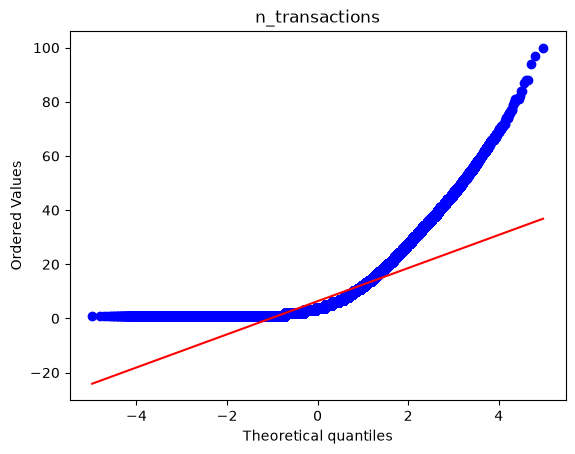

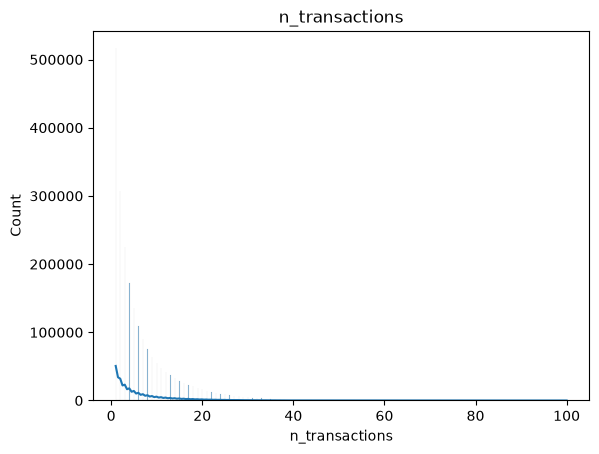

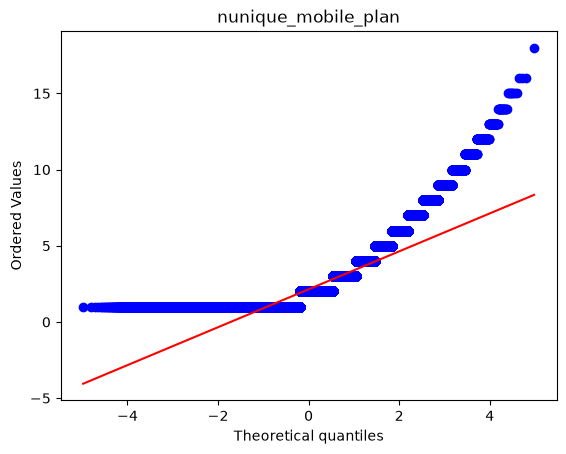

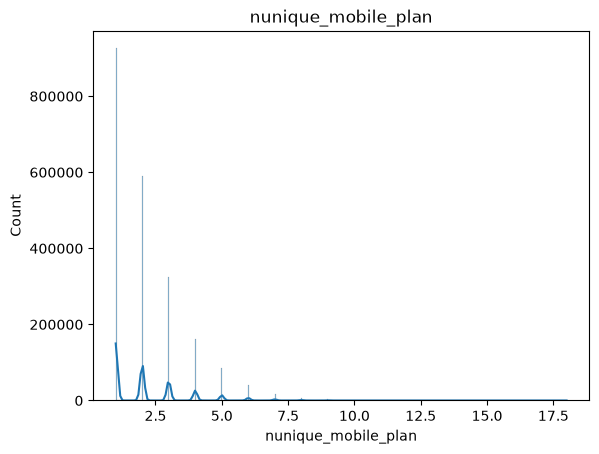

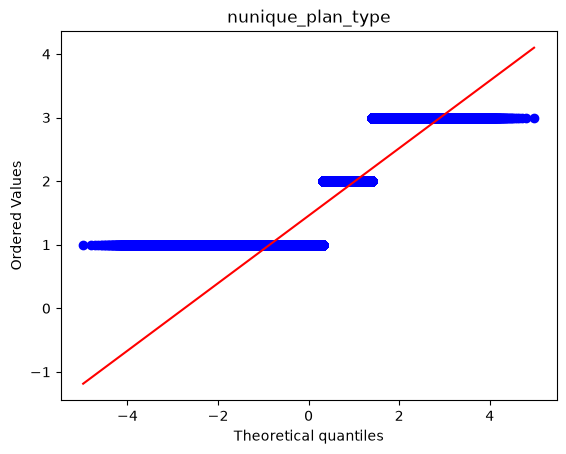

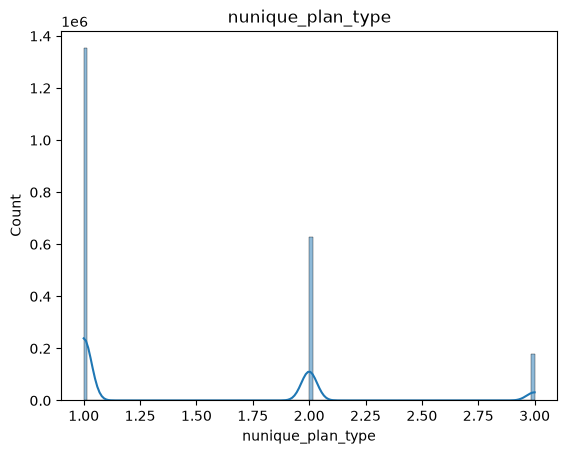

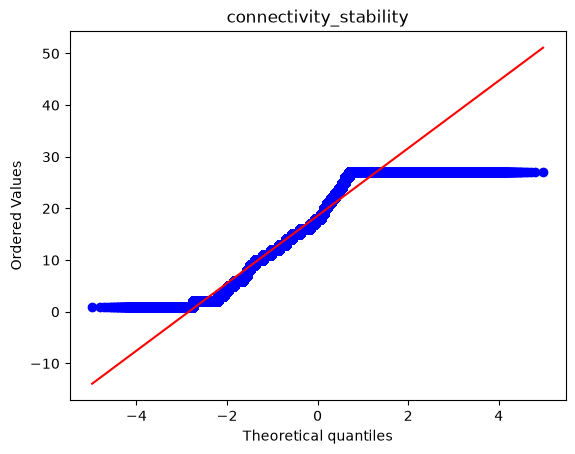

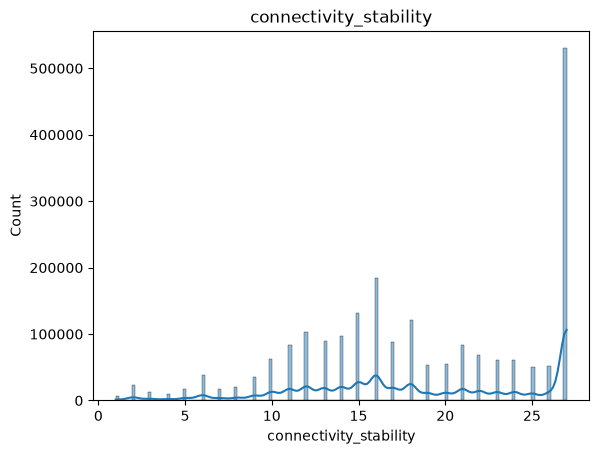

In [28]:
# Checking distribution to apply correct scaling.
'''
display(df_psm.describe())
stats.probplot(df_psm["n_transactions"], dist = "norm", plot = plt)
plt.title("n_transactions")
plt.show()

sns.histplot(df_psm["n_transactions"], kde = True)
plt.title("n_transactions")
plt.show()


stats.probplot(df_psm["nunique_mobile_plan"], dist = "norm", plot = plt)
plt.title("nunique_mobile_plan")
plt.show()

sns.histplot(df_psm["nunique_mobile_plan"], kde = True)
plt.title("nunique_mobile_plan")
plt.show()

stats.probplot(df_psm["nunique_plan_type"], dist = "norm", plot = plt)
plt.title("nunique_plan_type")
plt.show()

sns.histplot(df_psm["nunique_plan_type"], kde = True)
plt.title("nunique_plan_type")
plt.show()

stats.probplot(df_psm["connectivity_stability"], dist = "norm", plot = plt)
plt.title("connectivity_stability")
plt.show()

sns.histplot(df_psm["connectivity_stability"], kde = True)
plt.title("connectivity_stability")
plt.show()'''



In [5]:

x = df_psm.drop(
    ["UTCA", "VIP", "n_transactions", "nunique_plan_type", "nunique_mobile_plan", "app_user", "data/voice__ratio", "plans_bought/connectivity__ratio", "avg_transaction_ca"]
    , axis = 1)
y = df_psm["VIP"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 4, stratify = y)


scaler_std = StandardScaler()
cols_to_scale = ["connectivity_stability"] # , "n_transactions", "nunique_plan_type", "nunique_mobile_plan"

x_train[cols_to_scale] = scaler_std.fit_transform(x_train[cols_to_scale])
x_test[cols_to_scale] = scaler_std.transform(x_test[cols_to_scale])

encoder = OneHotEncoder(sparse_output = False, handle_unknown = "ignore").set_output(transform = "pandas")
cols_to_encod = ["prefered_channel", "prefered_data_tech", "prefered_geographic_classification", "prefered_region"]

enc_train = encoder.fit_transform(x_train[cols_to_encod])
x_train = x_train.drop(cols_to_encod, axis = 1).join(enc_train)

enc_test = encoder.transform(x_test[cols_to_encod])
x_test = x_test.drop(cols_to_encod, axis = 1).join(enc_test)

x_train.head()


,connectivity_stability,is_multi_plan_user,buys_data,buys_voice,buys_sms,prefered_channel_APP OM,prefered_channel_IVR,prefered_channel_MAXIT,prefered_channel_MBC,prefered_channel_USSD,...,prefered_region_Diana,prefered_region_Haute matsiatra,prefered_region_Ihorombe,prefered_region_Itasy,prefered_region_Melaky,prefered_region_Menabe,prefered_region_Sava,prefered_region_Sofia,prefered_region_Vakinankaratra,prefered_region_Vatovavy Fitovinany
msisdn,,,,,,,,,,,,,,,,,,,,,
261375678248,-1.116269,1,0,1,1,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
261324033750,0.110740,1,0,1,1,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
261376320459,0.756534,1,0,1,0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
261327984607,1.983542,1,0,1,0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
261324357376,-0.212157,1,1,1,0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:

lr = LogisticRegression(penalty = None)
lr.fit(x_train, y_train)

y_predic_lr = lr.predict(x_test)
display(classification_report(y_test, y_predic_lr))
print(classification_report(y_test, y_predic_lr))

# 17.0s

/stor/home/he4249/orange/my_custom_packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


'              precision    recall  f1-score   support\n\n           0       0.80      0.85      0.82    374377\n           1       0.68      0.61      0.64    200522\n\n    accuracy                           0.76    574899\n   macro avg       0.74      0.73      0.73    574899\nweighted avg       0.76      0.76      0.76    574899\n'

              precision    recall  f1-score   support

           0       0.80      0.85      0.82    374377
           1       0.68      0.61      0.64    200522

    accuracy                           0.76    574899
   macro avg       0.74      0.73      0.73    574899
weighted avg       0.76      0.76      0.76    574899



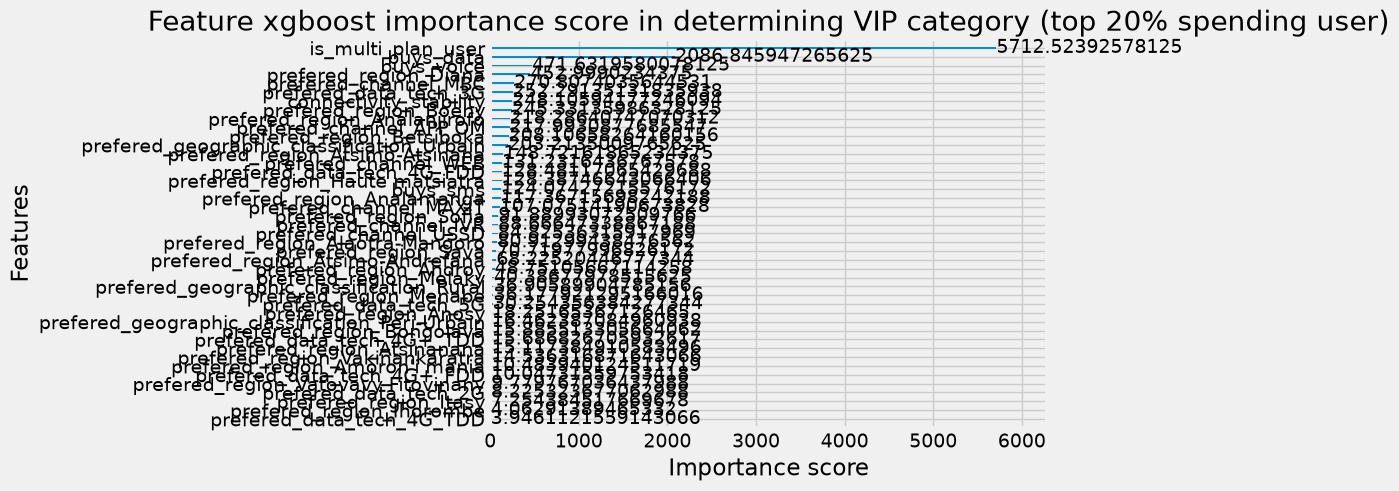

'              precision    recall  f1-score   support\n\n           0       0.82      0.86      0.84    374377\n           1       0.71      0.64      0.67    200522\n\n    accuracy                           0.78    574899\n   macro avg       0.76      0.75      0.75    574899\nweighted avg       0.78      0.78      0.78    574899\n'

              precision    recall  f1-score   support

           0       0.82      0.86      0.84    374377
           1       0.71      0.64      0.67    200522

    accuracy                           0.78    574899
   macro avg       0.76      0.75      0.75    574899
weighted avg       0.78      0.78      0.78    574899



In [ ]:
xgb_model = xgb.XGBClassifier(
    n_estimators = 150,
    max_depth = 6,
    learning_rate = 0.1,
    n_jobs = -1,
    tree_method = "hist",
    random_state = 4
)

xgb_model.fit(x_train, y_train)

# Gain measures the improvement in accuracy a feature brings to the branches it splits

xgb.plot_importance(xgb_model, importance_type = 'gain')

plt.title("Feature xgboost importance score in determining VIP category (top 20% spending user)")
plt.show()

y_predic_xgb = xgb_model.predict(x_test)
display(classification_report(y_test, y_predic_xgb))
print(classification_report(y_test, y_predic_xgb))

# 3.6s

In [7]:
# optuna don't forget scale_pos_weight

x = df_psm.drop([
    "UTCA", "VIP", "n_transactions", "nunique_plan_type", "nunique_mobile_plan",
    "app_user", "is_multi_plan_user", "buys_data", "buys_voice", "buys_sms", "prefered_data_tech",
    "data/voice__ratio", "plans_bought/connectivity__ratio", "avg_transaction_ca"
    ], axis = 1)
y = df_psm["VIP"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 4, stratify = y)


# Setting total server cores = (Optuna n_jobs) * (XGBoost n_jobs)
OPTUNA_TRIALS_AT_ONCE = 14
XGBOOST_CORES_PER_TRIAL = 8

cv_strategy = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 4)

cols_to_scale = ["connectivity_stability"]
cols_to_encod = ["prefered_channel", "prefered_geographic_classification", "prefered_region"]

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical_to_scale", StandardScaler(), cols_to_scale),
        ("caterogical_to_encode", OneHotEncoder(sparse_output = False, handle_unknown = "ignore"), cols_to_encod)
    ],
    remainder = "passthrough" # other features
)

# class imbalance for scale_pos_weight
ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])

def objective(trial):

    param = {
        "max_depth": trial.suggest_int("max_depth", 1, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.5, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "subsample": trial.suggest_float("subsample", 0.1, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.1, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 15),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
    }

    model = xgb.XGBClassifier(
        **param,
        objective = "binary:logistic",
        scale_pos_weight = ratio,
        tree_method = "hist",
        random_state = 4,
        eval_metric = "logloss",
        n_jobs = XGBOOST_CORES_PER_TRIAL
    )

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    scores = cross_val_score(
        pipeline,
        x_train,
        y_train,
        cv = cv_strategy,
        scoring = "neg_log_loss", # penalizing false predictions
        n_jobs = 1
    )

    return scores.mean()

study = optuna.create_study(direction = "maximize")
study.optimize(objective, n_trials = 150, n_jobs = OPTUNA_TRIALS_AT_ONCE)

print(f"Best log loss score: {study.best_value:.4f}")
print("Best Parameters:")
for key, value in study.best_params.items():
    print(f"{key}: {value}")

[I 2026-07-16 05:38:15,687] A new study created in memory with name: no-name-161c4589-a277-4b18-a3ae-ec33725ca107
[I 2026-07-16 05:40:21,164] Trial 7 finished with value: -0.5916228055953979 and parameters: {'max_depth': 9, 'learning_rate': 0.11480725484925655, 'n_estimators': 119, 'subsample': 0.8122592369944116, 'colsample_bytree': 0.9436431031781958, 'min_child_weight': 8, 'reg_alpha': 0.6153266713490971, 'reg_lambda': 0.00026000382285882174}. Best is trial 7 with value: -0.5916228055953979.
[I 2026-07-16 05:40:36,257] Trial 12 finished with value: -0.6016963481903076 and parameters: {'max_depth': 1, 'learning_rate': 0.1493991113899442, 'n_estimators': 350, 'subsample': 0.8355128426001324, 'colsample_bytree': 0.6411979336089014, 'min_child_weight': 5, 'reg_alpha': 0.18958887323141624, 'reg_lambda': 0.0020299428084852595}. Best is trial 7 with value: -0.5916228055953979.
[I 2026-07-16 05:40:40,982] Trial 9 finished with value: -0.5961983561515808 and parameters: {'max_depth': 2, 'lea

Best log loss score: -0.5901
Best Parameters:
max_depth: 12
learning_rate: 0.01652328144004374
n_estimators: 297
subsample: 0.101014017386578
colsample_bytree: 0.8755549232762643
min_child_weight: 1
reg_alpha: 0.16102604685773036
reg_lambda: 0.0004784037496382744


In [ ]:
# Non VIPs with the highest scores are users with the footprint of a high spender but who aren't spending yet which is untapped potential.

x = df_psm.drop([
    "UTCA", "VIP", "n_transactions", "nunique_plan_type", "nunique_mobile_plan",
    "app_user", "is_multi_plan_user", "buys_data", "buys_voice", "buys_sms", "prefered_data_tech",
    "data/voice__ratio", "plans_bought/connectivity__ratio", "avg_transaction_ca"
    ], axis = 1)
y = df_psm["VIP"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 4, stratify = y)


cols_to_scale = ["connectivity_stability"]
cols_to_encod = ["prefered_channel", "prefered_geographic_classification", "prefered_region"]

scaler_std = StandardScaler()
x_train[cols_to_scale] = scaler_std.fit_transform(x_train[cols_to_scale])
x_test[cols_to_scale] = scaler_std.transform(x_test[cols_to_scale])

encoder = OneHotEncoder(sparse_output = False, handle_unknown = "ignore").set_output(transform = "pandas")

enc_train = encoder.fit_transform(x_train[cols_to_encod])
x_train = x_train.drop(cols_to_encod, axis = 1).join(enc_train)

enc_test = encoder.transform(x_test[cols_to_encod])
x_test = x_test.drop(cols_to_encod, axis = 1).join(enc_test)


xgb_model = xgb.XGBClassifier(
    max_depth = 12,
    learning_rate = 0.01652328144004374,
    n_estimators = 297,
    subsample = 0.101014017386578,
    colsample_bytree = 0.8755549232762643,
    min_child_weight = 1,
    reg_alpha = 0.16102604685773036,
    reg_lambda = 0.0004784037496382744,
    n_jobs = -1,
    tree_method = "hist",
    eval_metric = "logloss",
    random_state = 4
)

xgb_model.fit(x_train, y_train)


y_predic_xgb = xgb_model.predict(x_test)

display(classification_report(y_test, y_predic_xgb))
print(classification_report(y_test, y_predic_xgb))

# 13.4s

'              precision    recall  f1-score   support\n\n           0       0.73      0.87      0.80    374377\n           1       0.63      0.41      0.50    200522\n\n    accuracy                           0.71    574899\n   macro avg       0.68      0.64      0.65    574899\nweighted avg       0.70      0.71      0.69    574899\n'

              precision    recall  f1-score   support

           0       0.73      0.87      0.80    374377
           1       0.63      0.41      0.50    200522

    accuracy                           0.71    574899
   macro avg       0.68      0.64      0.65    574899
weighted avg       0.70      0.71      0.69    574899



In [ ]:
x_full = df_psm.drop([
    "UTCA", "VIP", "n_transactions", "nunique_plan_type", "nunique_mobile_plan",
    "app_user", "is_multi_plan_user", "buys_data", "buys_voice", "buys_sms", "prefered_data_tech",
    "data/voice__ratio", "plans_bought/connectivity__ratio", "avg_transaction_ca"
    ], axis = 1)
cols_to_scale = ["connectivity_stability"]
cols_to_encod = ["prefered_channel", "prefered_geographic_classification", "prefered_region"]
scaler_std = StandardScaler()
x_full[cols_to_scale] = scaler_std.fit_transform(x_full[cols_to_scale])
encoder = OneHotEncoder(sparse_output = False, handle_unknown = "ignore").set_output(transform = "pandas")
enc_x = encoder.fit_transform(x_full[cols_to_encod])
x_full = x_full.drop(cols_to_encod, axis = 1).join(enc_x)



proba_vip = xgb_model.predict_proba(x_full)[:, 1]

df_psm_prb = df_psm.copy()
df_psm_prb["proba_vip"] = proba_vip

display(df_psm_prb[df_psm_prb["VIP"] == 0].sort_values("proba_vip", ascending = False)["proba_vip"].head())
display(df_psm_prb["proba_vip"].describe())
display(len(df_psm_prb[df_psm_prb["proba_vip"] >= 0.80]))

# 51167 non vips that act at 80% like a vip.

msisdn
261373051090    0.975961
261323553836    0.969064
261379103676    0.965459
261328852567    0.965455
261327709960    0.964877
Name: proba_vip, dtype: float32

count    2.874492e+06
mean     3.519003e-01
std      1.930920e-01
min      4.861123e-03
25%      2.041261e-01
50%      3.277681e-01
75%      4.865485e-01
max      9.767460e-01
Name: proba_vip, dtype: float64

51167

In [5]:
%%time

# PROPENSITY SCORE MATCHING: causal inference

# Does the use of app cause users to spend more money? (user to user comparaison)

'''
Underlying profile of someone who uses a Web App in Madagascar:
They must have a smartphone capable of downloading and running the app likely a 4G+ or 5G device.
They likely live in an urban center with strong internet coverage like Antananarivo.
They likely have a bank account or mobile money set up.
Now think about the profile of a strict USSD user:
They might be using a basic feature phone.
They might live in a rural area with intermittent coverage.
We need to block for counfonders.
'''


y = df_psm["app_user"]
x = df_psm.drop(
    ["UTCA", "prefered_channel", "VIP", "n_transactions", "nunique_plan_type", "nunique_mobile_plan", "app_user"]
    , axis = 1)

scaler_std = StandardScaler()
cols_to_scale = ["connectivity_stability", "data/voice__ratio", "plans_bought/connectivity__ratio", "avg_transaction_ca"]
x[cols_to_scale] = scaler_std.fit_transform(x[cols_to_scale])

encoder = OneHotEncoder(sparse_output = False, handle_unknown = "ignore").set_output(transform = "pandas")
cols_to_encod = ["prefered_data_tech", "prefered_geographic_classification", "prefered_region"]
enc_train = encoder.fit_transform(x[cols_to_encod])
x = x.drop(cols_to_encod, axis = 1).join(enc_train)


lr = LogisticRegression(penalty = None)
lr.fit(x, y)
psm = lr.predict_proba(x)



/stor/home/he4249/orange/my_custom_packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


CPU times: user 1min 56s, sys: 5min 10s, total: 7min 6s
Wall time: 12.8 s


In [6]:
%%time

df_psm["propensity_score"] = psm[ : , 1]

df_p = df_psm[df_psm["app_user"] == 1]
df_n = df_psm[df_psm["app_user"] == 0]

nn = NearestNeighbors(n_neighbors = 1, metric = "euclidean").fit(df_n[["propensity_score"]])
dists, indices = nn.kneighbors(df_p[["propensity_score"]])

# 2011 paper by biostatistician Peter C. Austin, "Optimal caliper widths for propensity score matching"
caliper = 0.2 * df_psm["propensity_score"].std()

matches_df = pd.DataFrame({
    "treat_idx": df_p.index,
    "control_idx": df_n.iloc[indices.flatten()].index,
    "distance": dists.flatten()
})

matches_df = matches_df[matches_df["distance"] <= caliper]

# With replacement

m_treat = df_psm.loc[matches_df["treat_idx"]]
m_control = df_psm.loc[matches_df["control_idx"]]

df_matched = pd.concat([m_treat, m_control])



CPU times: user 2.06 s, sys: 141 ms, total: 2.2 s
Wall time: 2.2 s


In [ ]:
treat_spend = m_treat["UTCA"]
control_spend = m_control["UTCA"]

financial_lift = treat_spend.mean() - control_spend.mean()

t, p_value = stats.ttest_ind(treat_spend, control_spend)
display(p_value)
# p = 0.0
display(financial_lift)
# 11854

0.0

11854.816656148829

In [14]:
%%time

df_p = df_psm[df_psm["app_user"] == 1]
df_n = df_psm[df_psm["app_user"] == 0]

# Sample 300000 for ~15% of data

df_n_common = df_n[df_n["propensity_score"] <= 0.26]
df_n_rare = df_n[df_n["propensity_score"] > 0.26]

df_n_common_downsampled = df_n_common.sample(n = 300000, random_state = 4)
df_n_downsampled = pd.concat([df_n_common_downsampled, df_n_rare])

df_lean = pd.concat([df_p, df_n_downsampled]).reset_index(drop=True)

caliper = 0.2 * df_psm["propensity_score"].std()

# No replacement this time
matcher = NearestNeighborMatch(
    replace = False,
    ratio = 1,
    random_state = 4,
    caliper = 0.2
)

df_matched = matcher.match(
    data = df_lean,
    treatment_col = "app_user",
    score_cols = ["propensity_score"]
)

m_treat = df_matched[df_matched["app_user"] == 1]
m_control = df_matched[df_matched["app_user"] == 0]

treat_spend = m_treat["UTCA"]
control_spend = m_control["UTCA"]

financial_lift = treat_spend.mean() - control_spend.mean()
t, p_value = stats.ttest_ind(treat_spend, control_spend)


CPU times: user 26min 33s, sys: 286 ms, total: 26min 33s
Wall time: 26min 33s


In [20]:

display(f"n treatment:{len(df_p)}")
display(f"matched n treatment:{len(m_treat)}")
display(f"n control:{len(df_n)}")
display(f"mean treatment spend:{treat_spend.mean():.2f}")
display(f"mean control spend:{control_spend.mean():.2f}")
display(f"financial_lift:{financial_lift:.2f}")
display(f"median fl:  {m_treat["UTCA"].median() - m_control["UTCA"].median():.2f}")
display(f"p_value:{p_value:.5e}")

# Did we drop too many treated units because the caliper couldn't find matches?
retention_rate = len(m_treat) / len(df_p) * 100
display(f"{retention_rate:.1f}%")

# Did the downsampled control group maintain the same score extremes?
display(f"Control range:   {df_n["propensity_score"].min():.4f} : {df_n["propensity_score"].max():.4f}")
display(f"downsampled control range:   {df_n_downsampled["propensity_score"].min():.4f} : {df_n_downsampled["propensity_score"].max():.4f}")


'''
The 82.0% retention rate shows the caliper worked. ~35 000 app users dropped.
The downsampled control pool perfects the control range.

Matching with replacement difference is that some high spending legacy were cloned many times
which inflated the control group's average and created the +11854 UTCA.
Without replacement made a 1-to-1 mapping that removed the clones.
Uplift with one to one match: +27892.58 UTCA

The application is a definitively profitable channel that objectively drives higher individual spending compared
to identical users operating on legacy technologies. Median lift proves that the change is data wide and of AT LEAST 8650 ar.
'''


'n treatment:194907'

'matched n treatment:159787'

'n control:2679585'

'mean treatment spend:39544.89'

'mean control spend:27892.58'

...

'p_value:0.00000e+00'

'82.0%'

'Control range:   0.0013 : 1.0000'

'downsampled control range:   0.0013 : 1.0000'

"\nThe 82.0% retention rate shows the caliper worked. ~35 000 app users dropped.\nThe downsampled control pool perfects the control range.\n\nMatching with replacement difference is that some high spending legacy were cloned many times\nwhich inflated the control group's average and created the +11854 UTCA.\nWithout replacement made a 1-to-1 mapping that removed the clones.\nUplift with one to one match: +27892.58 UTCA\n\nThe application is a definitively profitable channel that objectively drives higher individual spending compared\nto identical users operating on legacy technologies. Median lift proves that the change is data wide and of AT LEAST 8650 ar.\n"

In [16]:
# Checking distribution of sampled data is accurate

percentiles = [10, 25, 50, 75, 90, 95, 99]

dist_table = pd.DataFrame({
    "control": np.percentile(df_n["propensity_score"], percentiles),
    "downsampled control": np.percentile(df_n_downsampled["propensity_score"], percentiles),
    "treatment": np.percentile(df_p["propensity_score"], percentiles)
}, index = percentiles)

display(dist_table.round(4))

# how many available matches exist at the high end
high_tier_treatment = len(df_p[df_p["propensity_score"] > 0.26])
high_tier_control = len(df_n[df_n["propensity_score"] > 0.26])
high_tier_control_down = len(df_n_downsampled[df_n_downsampled["propensity_score"] > 0.26])

print(f"treatment:{high_tier_treatment}")
print(f"control:{high_tier_control}")
print(f"downsampled control:{high_tier_control_down}")

,control,downsampled control,treatment
10,0.0055,0.0065,0.0319
25,0.0112,0.0131,0.0795
50,0.0262,0.0402,0.1648
75,0.0775,0.1781,0.2375
90,0.1712,0.3069,0.3166
95,0.2209,0.3634,0.3815
99,0.3324,0.5497,0.5597


treatment:37831
control:73384
downsampled control:73384


In [17]:
%%time

x = df_psm.drop(["UTCA", "app_user", "plans_bought/connectivity__ratio", "avg_transaction_ca"], axis = 1)
y = df_psm["UTCA"]
t = df_psm["app_user"]

x_train, x_test, t_train, t_test, y_train, y_test = train_test_split(x, t, y, test_size = 0.2, random_state = 4)

cols_to_scale = ["connectivity_stability", "n_transactions", "nunique_mobile_plan", "nunique_plan_type",
                "data/voice__ratio"]
cols_to_encod = ["prefered_channel", "prefered_geographic_classification", "prefered_region", "prefered_data_tech"]


scaler_std = StandardScaler()
x_train[cols_to_scale] = scaler_std.fit_transform(x_train[cols_to_scale])
x_test[cols_to_scale] = scaler_std.transform(x_test[cols_to_scale])

encoder = OneHotEncoder(sparse_output = False, handle_unknown = "ignore").set_output(transform = "pandas")

enc_train = encoder.fit_transform(x_train[cols_to_encod])
x_train = x_train.drop(cols_to_encod, axis = 1).join(enc_train)

enc_test = encoder.transform(x_test[cols_to_encod])
x_test = x_test.drop(cols_to_encod, axis = 1).join(enc_test)


m_causal = xgb.XGBRegressor(
    n_estimators = 300,
    max_depth = 12,
    learning_rate = 0.0165,
    tree_method = "hist",
    n_jobs = -1,
    random_state = 4
)


t_learner = BaseTRegressor(learner = m_causal)


t_learner.fit(X = x_train, treatment = t_train, y = y_train)

ite_app = t_learner.predict(x_test)
ite_train = t_learner.predict(x_train)


CPU times: user 42min 30s, sys: 3.91 s, total: 42min 34s
Wall time: 29.7 s


,n_transactions,nunique_mobile_plan,nunique_plan_type,connectivity_stability,is_multi_plan_user,buys_data,buys_voice,buys_sms,data/voice__ratio,VIP,...,prefered_region_Vatovavy Fitovinany,prefered_data_tech_2G,prefered_data_tech_3G,prefered_data_tech_4G+_FDD,prefered_data_tech_4G+_TDD,prefered_data_tech_4G_FDD,prefered_data_tech_4G_TDD,prefered_data_tech_5G,predicted_uplift_UTCA,is_app_user
msisdn,,,,,,,,,,,,,,,,,,,,,
261320783848,-1.296551,-0.950827,-0.815461,0.497757,0,0,0,0,0.847011,1,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.730463e+06,0
261373095594,0.225131,0.254182,-0.815461,-1.891470,1,1,0,0,2.000549,1,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4.797081e+05,0
261322706306,2.858287,0.254182,-0.815461,-1.052012,1,1,0,0,21.482524,1,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.649402e+05,0
261328030118,2.302550,1.459190,-0.815461,-0.987438,1,1,0,0,12.254220,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.989520e+05,0
261329084825,2.104615,3.869206,0.596652,0.110315,1,1,1,0,-0.178356,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.713866e+05,0
261327255578,1.887140,4.270875,0.596652,-0.083406,1,1,1,0,3.090001,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.565663e+05,0
261373160878,-0.641198,-0.147488,-0.815461,0.562331,1,1,0,0,1.231523,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.478896e+05,0
261376393053,1.708217,1.057520,2.008766,-1.310307,1,1,1,1,-0.226420,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.317285e+05,0
261378198064,-0.641198,-0.549157,-0.815461,0.562331,1,1,0,0,1.231523,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.220590e+05,0


count    2.679585e+06
mean     1.384777e+03
std      7.648968e+03
min     -6.712204e+06
25%      1.484137e+02
50%      4.423678e+02
75%      1.138060e+03
max      1.730463e+06
Name: predicted_uplift_UTCA, dtype: float64

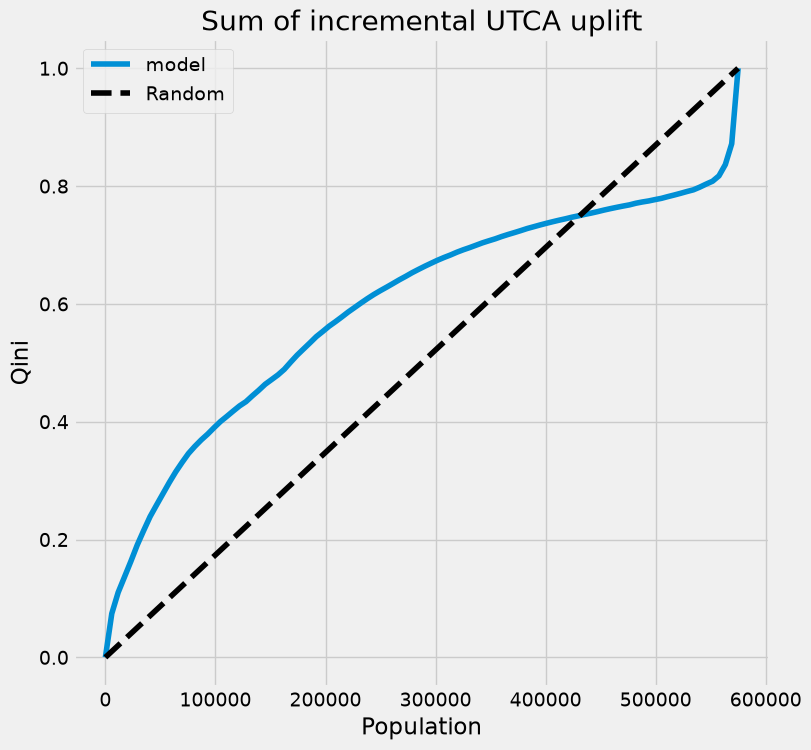

CPU times: user 3.15 s, sys: 1.1 s, total: 4.25 s
Wall time: 4.05 s


In [18]:
%%time

df_train_ite = x_train.copy()
df_train_ite["predicted_uplift_UTCA"] = ite_train
df_train_ite["is_app_user"] = t_train

df_test_ite = x_test.copy()
df_test_ite["predicted_uplift_UTCA"] = ite_app
df_test_ite["is_app_user"] = t_test

df_ite = pd.concat([df_train_ite, df_test_ite])


df_ite_legacy = df_ite[df_ite["is_app_user"] == 0]

df_ite_legacy = df_ite_legacy.sort_values(by = "predicted_uplift_UTCA", ascending = False)

display(df_ite_legacy.head(10))
display(df_ite_legacy["predicted_uplift_UTCA"].describe())

df_eval = pd.DataFrame({
    "y": y_test,
    "treatment": t_test,
    "model": ite_app.flatten()
})

# Qini curve
plot_qini(df_eval, outcome_col = "y", treatment_col = "treatment", normalize = True)
plt.title("Sum of incremental UTCA uplift")
plt.show()

In [ ]:
'''
The apps do additional revenue for the business but only for a subset of legacy users
Ranking users by their predicted financial lift
so we can find the maximum possible revenue while preventing the customer churn

The model assumes the apps cause the increased spending.

However, the data lacks variables like age, profession, and income.
It is probable that being young and wealthy causes both app adoption and higher spending.
If the model is just capturing "wealth" rather than the App's true causal effect, the predicted lifts will be overestimated.

The data lacks variables information about the phone: a recent smartphone, an older model, or a mobile payment terminal.
Could predict an app uplift for a user who cannot install the apps because they are using an old phone.

The data lacks variables information about data/voice consumption.
The model assumes an increase in purchasing but we don't know if the users are usings what they bought.

The data lacks activation dates so the model treats all customers the same
But old and recent users can help us understand how stable their are

'''

# The graphs tells us that 13% of top uplift legacy users bring addiotnal revenue
# df_ite_legacy.index[: 350000]
#0.13*2679585

with open("legacy_uplifted_msisdn_list.txt", "w") as f:
    for item in df_ite_legacy.index[: 350000]:
        f.write(f"{item}\n")



with open("legacy_uplifted_values_list.txt", "w") as f:
    for item in df_ite_legacy["predicted_uplift_UTCA"][: 350000].to_list():
        f.write(f"{item}\n")

# Understand those user. # k prototypes Clustering

In [ ]:
i = []
with open("legacy_uplifted_msisdn_list.txt", "r") as f:
    line = f.readline().strip()
    while line:
        i.append(line)
        line = f.readline().strip()

top_users_idx = i
df_clustering = df_psm.loc[top_users_idx]


df_clustering = df_clustering.drop(["UTCA", "app_user", "VIP", "propensity_score"], axis = 1) # drop "propensity_score" depending on it is ran


# Untouched: is_multi_plan_user	buys_data	buys_voice	buys_sms
cols_to_scale = ["connectivity_stability", "n_transactions", "nunique_mobile_plan", "nunique_plan_type",
                "data/voice__ratio", "plans_bought/connectivity__ratio", "avg_transaction_ca"]
cols_to_encod = ["prefered_channel", "prefered_geographic_classification", "prefered_region", "prefered_data_tech"]


scaler_std = StandardScaler()
df_clustering[cols_to_scale] = scaler_std.fit_transform(df_clustering[cols_to_scale])


df_clustering_sampled = df_clustering.sample(n = 100000, random_state = 4)

cat_indexes = [df_clustering.columns.get_loc(c) for c in cols_to_encod]





np.int64(6)

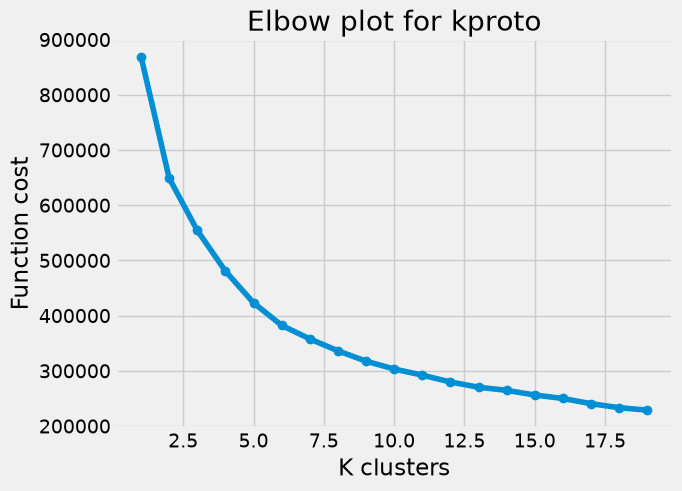

CPU times: user 27.1 s, sys: 4.44 s, total: 31.5 s
Wall time: 1h 1min 31s


In [4]:
%%time

costs = []
k_range = range(1, 20)
for k in k_range:
    kproto = KPrototypes(n_clusters = k, n_jobs = -1, random_state = 4)
    kproto.fit(df_clustering_sampled, categorical = cat_indexes)
    costs.append(kproto.cost_)

kl = KneeLocator(
    x = list(k_range),
    y = costs,
    curve = "convex",
    direction = "decreasing"
)

optimal_k = kl.elbow
display(optimal_k)

plt.plot(k_range, costs, marker = "o")
plt.title("Elbow plot for kproto")
plt.xlabel("K clusters")
plt.ylabel("Function cost")
plt.show()

In [26]:
%%time

# Checking if k = 6 makes sense on sampled data

optimal_k = 6
kproto = KPrototypes(n_clusters = optimal_k, n_jobs = -1, random_state = 4)
labels = kproto.fit_predict(df_clustering_sampled, categorical = cat_indexes)

# Attach clusters
df_eval = df_clustering_sampled.copy()
df_eval["cluster"] = labels

# Size
display(df_eval["cluster"].value_counts(normalize = True))

display(df_eval.groupby("cluster").mean(numeric_only = True))
display(df_eval.groupby("cluster").median(numeric_only = True))

cluster
0    0.35593
1    0.23986
2    0.21294
5    0.13826
3    0.04967
4    0.00334
Name: proportion, dtype: float64

,n_transactions,nunique_mobile_plan,nunique_plan_type,connectivity_stability,is_multi_plan_user,buys_data,buys_voice,buys_sms,data/voice__ratio,plans_bought/connectivity__ratio,avg_transaction_ca
cluster,,,,,,,,,,,
0,0.276822,0.402860,0.643497,-0.161468,1.000000,0.940494,0.998286,0.295002,-0.156209,-0.019937,-0.103194
1,-0.257494,-0.425156,-0.801194,1.215191,0.987159,0.169432,0.984074,0.068707,-0.343105,-0.649616,-0.100672
2,-1.025790,-0.810030,-0.685849,-0.661648,0.846999,0.433690,0.820607,0.047009,-0.067467,-0.415442,0.167553
3,0.533569,-0.836659,-0.508258,0.112059,0.824240,1.000000,0.321522,0.105899,3.450591,0.126913,-0.108092
4,-2.997846,-1.534733,-1.080745,-0.440915,0.176647,0.766467,0.029940,0.000000,0.482830,-0.932230,14.213100
5,1.177985,1.269760,0.991699,-0.709136,0.999855,0.976494,0.999494,0.501808,-0.161874,1.801382,-0.123386


,n_transactions,nunique_mobile_plan,nunique_plan_type,connectivity_stability,is_multi_plan_user,buys_data,buys_voice,buys_sms,data/voice__ratio,plans_bought/connectivity__ratio,avg_transaction_ca
cluster,,,,,,,,,,,
0,0.302721,0.316592,0.308161,-0.328466,1.0,1.0,1.0,0.0,-0.315932,-0.066968,-0.127222
1,-0.256143,-0.467609,-1.119207,1.260282,1.0,0.0,1.0,0.0,-0.397361,-0.707737,-0.113377
2,-0.948088,-0.859710,-1.119207,-0.709766,1.0,0.0,1.0,0.0,-0.397361,-0.569544,-0.106607
3,0.509277,-0.859710,-1.119207,-0.010717,1.0,1.0,0.0,0.0,2.941206,-0.089572,-0.112893
4,-3.163536,-1.643911,-1.119207,-0.519116,0.0,1.0,0.0,0.0,0.498352,-0.956188,10.777351
5,1.178367,1.100794,0.308161,-0.836866,1.0,1.0,1.0,1.0,-0.288790,1.489926,-0.131830


CPU times: user 6.29 s, sys: 475 ms, total: 6.76 s
Wall time: 11min 32s


In [5]:
%%time

# Full data

optimal_k = 6
kproto = KPrototypes(n_clusters = optimal_k, n_jobs = -1, random_state = 4)
labels = kproto.fit_predict(df_clustering, categorical = cat_indexes)

# Attach clusters
df_f_eval = df_clustering.copy()
df_f_eval["cluster"] = labels

/stor/home/he4249/orange/my_custom_packages/kmodes/kprototypes.py:11: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.5.1)
  from scipy import sparse
/stor/home/he4249/orange/my_custom_packages/kmodes/kprototypes.py:11: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.5.1)
  from scipy import sparse
/stor/home/he4249/orange/my_custom_packages/kmodes/kprototypes.py:11: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.5.1)
  from scipy import sparse
/stor/home/he4249/orange/my_custom_packages/kmodes/kprototypes.py:11: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.5.1)
  from scipy import sparse
/stor/home/he4249/orange/my_custom_packages/kmodes/kprototypes.py:11: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detect

CPU times: user 10.8 s, sys: 996 ms, total: 11.8 s
Wall time: 13min 8s


In [6]:
v = []
with open("legacy_uplifted_values_list.txt", "r") as f:
    line = f.readline().strip()
    while line:
        v.append(float(line))
        line = f.readline().strip()

df_f_eval["predicted_uplift_UTCA"] = v


df_f_eval.groupby("cluster").mean(numeric_only = True)

,n_transactions,nunique_mobile_plan,nunique_plan_type,connectivity_stability,is_multi_plan_user,buys_data,buys_voice,buys_sms,data/voice__ratio,plans_bought/connectivity__ratio,avg_transaction_ca,predicted_uplift_UTCA
cluster,,,,,,,,,,,,
0,-2.985917,-1.534588,-1.078080,-0.427022,0.188136,0.771186,0.025424,0.001695,0.488680,-0.933788,14.493927,37608.047413
1,0.246049,0.377667,0.629525,-0.159807,1.000000,0.938644,0.997842,0.287796,-0.153618,-0.040602,-0.102357,8294.514299
2,1.165269,1.271918,0.989483,-0.683395,0.999843,0.976846,0.999351,0.499931,-0.160999,1.725688,-0.122925,12537.157803
3,-1.041626,-0.831591,-0.711996,-0.660842,0.840516,0.420674,0.815946,0.046034,-0.068677,-0.417577,0.171687,7398.476441
4,0.527850,-0.846681,-0.508640,0.100620,0.815617,1.000000,0.317583,0.109433,3.446174,0.134595,-0.110818,11948.853286
5,-0.247933,-0.423761,-0.811267,1.215273,0.988055,0.163947,0.984739,0.066550,-0.344695,-0.646346,-0.101981,6525.911884


In [7]:
df_f_eval.groupby("cluster").describe(include = "object")

/tmp/ipykernel_3425353/500338573.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_f_eval.groupby("cluster").describe(include = "object")
/tmp/ipykernel_3425353/500338573.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtyp

prefered_channel                     prefered_data_tech         \
                   count unique   top   freq              count unique   
cluster                                                                  
0                   1180      4  USSD   1005               1180      6   
1                 125106      3   IVR  77266             125106      7   
2                  50833      3   IVR  28090              50833      7   
3                  72120      4   IVR  45327              72120      7   
4                  17545      3   IVR   8320              17545      6   
5                  83216      3   IVR  65398              83216      7   

                        prefered_geographic_classification                 \
             top   freq                              count unique     top   
cluster                                                                     
0             5G    461                               1180      3  Urbain   
1         4G_FDD  39193                             125106      3  Urbain   
2        4G+_FDD  19238                              50833      3  Urbain   
3         4G_FDD  25114                              72120      3  Urbain   
4        4G+_TDD   4699                              17545      3  Urbain   
5             3G  31205                              83216      3   Rural   

               prefered_region                            
          freq           count unique         top   freq  
cluster                                                   
0          841            1180     20  Analamanga    951  
1        79716          125106     22       Diana  44251  
2        39481           50833     22       Diana  21272  
3        40000           72120     22       Diana  18189  
4        11382           17545     22  Analamanga   7888  
5        43351           83216     22       Diana  26598

In [13]:
with open("cible_ideal_msisdn.txt", "w") as f:
    for item in df_f_eval[df_f_eval["cluster"] == 2].reset_index()["msisdn"].to_list():
        f.write(f"{item}\n")